# Exercício 1: Teorema Central do Limite

Considere o **Teorema Central do Limite (TCL)**. Sejam $X_1, \ldots, X_n$ variáveis aleatórias i.i.d., com média $\mu$ e variância finita $\sigma^2$. Então,

$$
\frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}
\xrightarrow{d}
N(0,1),
$$

quando $n \to \infty$.

O objetivo deste exercício é verificar empiricamente o comportamento descrito pelo TCL para diferentes distribuições e diferentes valores de $n$.

1. Considere as seguintes distribuições para $X$:

   * Uniforme;
   * Bernoulli;
   * Geométrica;
   * Poisson.

   Para cada distribuição, escolha diferentes valores de $n$ e gere $M = 5000$ realizações da variável aleatória

   $$
   Z_n = \frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}.
   $$

   Compare o comportamento da distribuição de $Z_n$ conforme o valor de $n$ aumenta.

2. Para cada distribuição e para cada valor de $n$, construa um histograma das $M = 5000$ realizações de $Z_n$.

   Compare os histogramas obtidos com uma amostra de uma distribuição normal padrão $N(0,1)$ gerada diretamente pelo NumPy.

3. Analise os resultados obtidos e discuta:

   * como a aproximação pela distribuição normal muda conforme $n$ aumenta;
   * quais distribuições apresentam convergência mais rápida para a normal;
   * como o formato da distribuição original influencia a qualidade da aproximação para valores pequenos de $n$.


-1.4705584375898426
[np.float64(-0.6077203989090197), np.float64(1.0203981112128628), np.float64(-0.47878012257197305), np.float64(0.729904176002704), np.float64(1.3115092110719584), np.float64(0.5329319410127664), np.float64(-0.61748988027935), np.float64(0.21670530755808054), np.float64(-0.9885123129700655), np.float64(-0.9786082865320636), np.float64(0.23453388398955644), np.float64(-1.7225510753395221), np.float64(0.19207404657059307), np.float64(0.2716488830133801), np.float64(-0.7858751963456035), np.float64(-1.989868598341701), np.float64(0.21811992702261232), np.float64(-1.0376641280316108), np.float64(0.19305051175316412), np.float64(-1.6631877373626436), np.float64(-1.082833519920581), np.float64(0.2454582585978643), np.float64(0.3286591959726221), np.float64(0.7324065056954258), np.float64(0.7228966253133199), np.float64(-0.35716094659651426), np.float64(-0.6598141518155536), np.float64(-0.8543639439415257), np.float64(-1.4697279395409588), np.float64(-1.1349025310997911), n

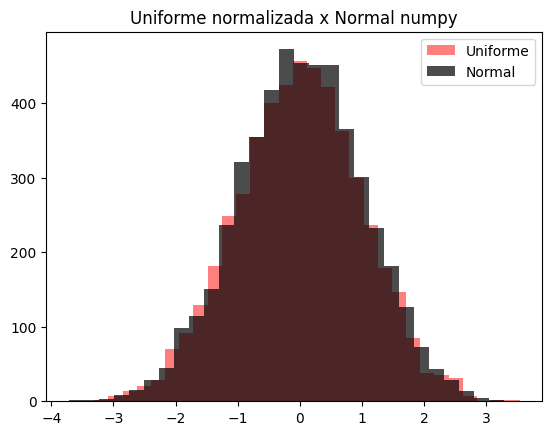

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import time

M = 5000
n = 10
p = .5
amostra = []
#Uniforme
for i in range(M):
  amostra_uniforme = np.random.uniform(size=n)
  Zu = n** .5 *(np.mean(amostra_uniforme) - .5) / (1/12)**.5
  amostra.append(Zu)

#Montando a normal padrão a partir da np

normal = np.random.normal(size=M)
print(Zu)
print(amostra)

plt.hist(amostra, bins =30, alpha=.5 ,color='red', label='Uniforme')
plt.hist(normal, bins =30, alpha=.7, color='black', label='Normal')
plt.legend()
plt.title('Uniforme normalizada x Normal numpy')
plt.show()


 A partir de n=10, a amostra ja se aproxima da normal. Sendo considerada uma aproximação rápida

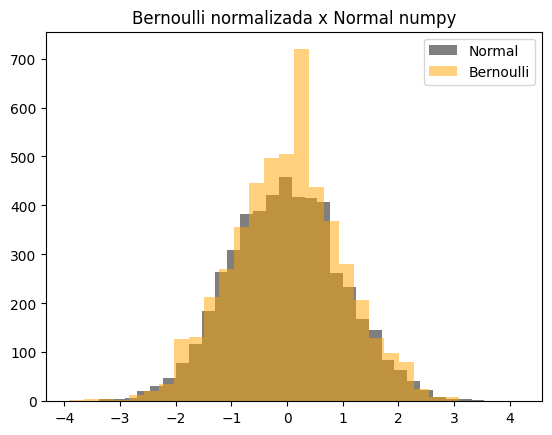

In [35]:
#Bernoulli
n = 250
amostrab = []
bern = np.mean(np.random.uniform(size=n) < p)

plt.hist(np.random.normal(size=M), bins=30, alpha=.5, color ='black', label = 'Normal')
plt.hist((n**.5 * (np.mean(np.random.uniform(size=(M, n)) >p , axis=1) - .5) / (1/4)**.5), bins=30, alpha=.5, color = 'orange', label='Bernoulli')
plt.title('Bernoulli normalizada x Normal numpy')
plt.legend()
plt.show()

A partir de em média n=250, a amostra ja se aproxima da normal. Sendo considerada uma aproximação demorada

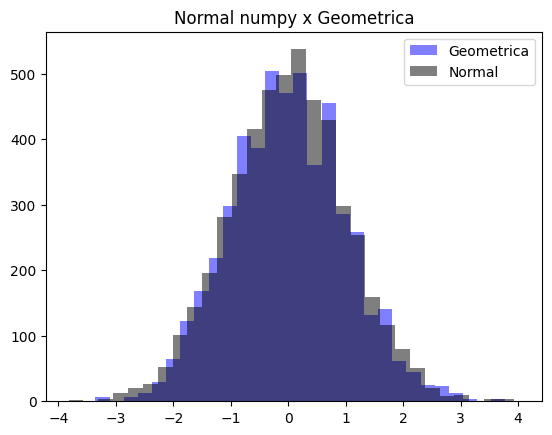

In [36]:
#Geométrica
n = 250
E = 1/p
Var = (1-p)/p**2
amostrag = []
for i in range(M):
  u = np.random.uniform(size=(n))
  i = (n**.5 *(np.mean(np.ceil(np.log(u)/np.log(1-p)))-2)*(1/2)**.5)

  amostrag.append(i)
plt.hist(amostrag, bins=30, alpha=.5, color='blue', label='Geometrica')
plt.hist(np.random.normal(size=M), alpha=.5, bins=30, color='black', label= 'Normal')
plt.title('Normal numpy x Geometrica')
plt.legend()
plt.show()

A partir de em média n=250, a amostra ja se aproxima da normal. Sendo considerada uma aproximação demorada

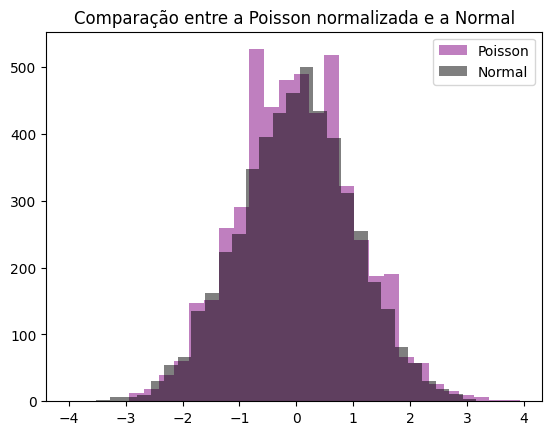

In [37]:
#Poisson
M = 5000
n = 50
amostra = []
for i in range(M):
  amostrinha = []
  for j in range(n):
    i = 0
    lamb = 3
    po = np.exp(-lamb)
    F = po
    u = np.random.uniform()
    while u > F:
      i += 1
      po = po*(lamb/i)
      F += po
    amostrinha.append(i)
  z = n**.5*(np.mean(amostrinha)-lamb)*(1/lamb)**.5
  amostra.append(z)


#amostrap.append(n**.5*(np.mean(i)-lamb)*(1/lamb)**.5)

plt.hist(amostra, bins=30, color = 'purple', label = 'Poisson', alpha=.5)
plt.hist(np.random.normal(size=M), alpha=.5, bins=30, color='black', label= 'Normal')
plt.legend()
plt.title('Comparação entre a Poisson normalizada e a Normal')
plt.show()

A partir de em média n=50, a amostra ja se aproxima da normal. Sendo considerada uma aproximação rápida

Quanto maior for o n, mais próximo da normal será a distribuição;
A bernoulli e a binomial se aproximam da normal mais rapido que as demais;
As distribuições que se aproximam mais rapido estão concentradas em torno da méda da normal


# Exercício 2: Aproximação de Poisson

Como vimos em sala, se$X_n \sim \operatorname{Binomial}(n,p_n),$ com $p_n = \frac{\lambda}{n},$ então, para $\lambda > 0$ fixo,

$$
X_n \xrightarrow{d} \operatorname{Poisson}(\lambda)
$$

quando $n \to \infty$.

Em outras palavras, quando $n$ aumenta e $p_n$ diminui de forma que $np_n = \lambda,$ a distribuição $\operatorname{Binomial}(n,p_n)$ se aproxima de uma distribuição $\operatorname{Poisson}(\lambda)$.

1. Fixe um valor de $\lambda$ e um tamanho de amostra $M$. Para diferentes valores de $n$:

   * defina $p_n = \lambda/n$;
   * gere uma amostra de tamanho $M$ de variáveis

   $$
   X_n \sim \operatorname{Binomial}\left(n,\frac{\lambda}{n}\right);
   $$

   * compare as distribuições obtidas para diferentes valores de $n$ e analise o efeito do aumento de $n$ na aproximação pela distribuição de Poisson.

2. Para verificar a qualidade da aproximação, compare as amostras obtidas pelo método binomial com:

   * uma amostra de tamanho $M$ gerada diretamente por `numpy.random.poisson`;
   * uma amostra de tamanho $M$ de variáveis $\operatorname{Poisson}(\lambda)$ geradas utilizando o **método recursivo**.

3. Para cada método, construa histogramas ou gráficos de frequências e compare as distribuições empíricas obtidas.

4. Compare também o **tempo de execução** dos dois métodos:

   * aproximação por $\operatorname{Binomial}(n,\lambda/n)$;
   * geração de Poisson pelo método da inversão.

5. Discuta os resultados obtidos, considerando:

   * como o valor de $n$ influencia a qualidade da aproximação binomial-Poisson;
   * se as distribuições empíricas produzidas pelos três métodos são semelhantes;
   * as diferenças de tempo de execução entre os métodos;
   * as vantagens e desvantagens de cada método de geração.


O tempo na aproximação da binomial pra poisson é de 0.657 segundos
O tempo na poisson pelo método da inversão é de 0.063983 segundos


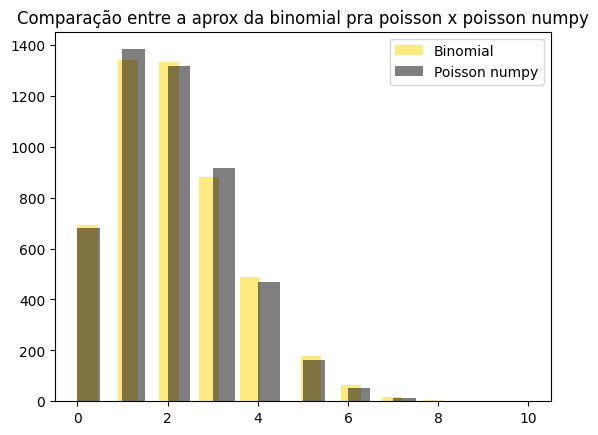

In [59]:
lamb = 2
i = time.time()
M = 5000
amostra = []
n = 10000
p = lamb/n
binom = np.sum(np.random.uniform(size=(M, n)) < p, axis=1)

f = time.time()
t = f - i
print(f'O tempo na aproximação da binomial pra poisson é de {t:.3f} segundos')

i2 = time.time()

amostra2 = []
for i in range(n):
  u = np.random.uniform()
  lamb = 2
  i = 0
  p = np.exp(-lamb)
  F = p
  while u > F:
    i += 1
    p = p*(lamb/i)
    F += p
    X = i
  amostra2.append(X)

f2 = time.time()
t2 = f2 - i2
print(f'O tempo na poisson pelo método da inversão é de {t2:3f} segundos')
plt.hist(binom,  bins=20, alpha=.5, color='gold', label='Binomial')
plt.hist(np.random.poisson(lamb, size=M),bins=20, alpha =.5, color='black', label='Poisson numpy')
plt.title('Comparação entre a aprox da binomial pra poisson x poisson numpy')
plt.legend()
plt.show()

5. Discuta os resultados obtidos, considerando:

   * como o valor de $n$ influencia a qualidade da aproximação binomial-Poisson;
   * se as distribuições empíricas produzidas pelos três métodos são semelhantes;
   * as diferenças de tempo de execução entre os métodos;
   * as vantagens e desvantagens de cada método de geração.


* Quanto maior o n, melhor fica a qualidade da aproximação
* O método da inversão é mais rapido do que na aproximação
* Ambas tem um laço que pesa muito
